In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# Load the long read samples list
#samples = [sample for sample in pd.read_table('/gpfs/data/user/shweta_lab/data/TE/TE_discovery/longreads/all_longread_samples.txt', names=['sampleID'])['sampleID']]
samples = ['AP97317807JI', 'AR21470926BU', 'BV84758993ZD', 'CS37349708SW', 'EE01709405UW', 'FU52780557SM', 'GY49105560UL', 'HO76179874OQ', 'KN45604014OF', 'OB84743249OV','PH33227146TP', 'SF20790699II', 'UT72239905LP', 'WA39086099MA', 'YQ42560871PO', 'ZR29322449IE']
print(samples) # 16 samples

['AP97317807JI', 'AR21470926BU', 'BV84758993ZD', 'CS37349708SW', 'EE01709405UW', 'FU52780557SM', 'GY49105560UL', 'HO76179874OQ', 'KN45604014OF', 'OB84743249OV', 'PH33227146TP', 'SF20790699II', 'UT72239905LP', 'WA39086099MA', 'YQ42560871PO', 'ZR29322449IE']


In [3]:
# loading xtea and sniffles results onto a dataframe
xtea_results = {}
sniffles_results = {}
for sample in samples:
    sniffles_results[sample] = pd.read_csv(f'/gpfs/data/user/shweta_lab/data/TE/TE_discovery/longreads/sniffles2/{sample}_ins.table', sep='\t')
    for TE in ['ALU','LINE1', 'SVA', 'HERVK']:
        xtea_results[f'{sample}_{TE}'] = pd.read_csv(f'/gpfs/data/user/shweta_lab/data/TE/TE_discovery/longreads/xtea/{sample}/classified_results.txt.merged_{TE}.txt', sep='\t', names=['CHROM', 'POS', 'type', 'structure', 'left segment', 'right segment', 'TSD', "5' transduction", "3' transduction", 'insertion sequence', "5' transduction sequence", "3' transduction sequence", 'polyA'])

In [6]:
TE_list = ['ALU', 'LINE1']
Temp_dir = "/gpfs/data/user/ruchitha/MELT/Analysis/Characterisation/scripts/TMP_files_7478/without_alt_noac0_norandom"
genotypes_to_include = ['0/1', '1/0', '1/1']
MELT_results = {}

for te in TE_list:
    vartype = 'Raw'
    file_path = f'{Temp_dir}/{te}_{vartype}_df.tsv.gz'
    
    print(f"Reading {file_path}...")
    df = pd.read_csv(file_path, sep="\t")
    
    for sample in samples:
        col = f'{sample}_md'
        if col not in df.columns:
            print(f"  WARNING: {col} not found in {te} df, skipping")
            continue
        MELT_results[f'{sample}_{te}'] = df[df[col].isin(genotypes_to_include)].reset_index(drop=True)
    
    df = None  # free memory before next TE
    print(f"  Done. {len(samples)} sample subsets stored for {te}")

print(f"\nTotal keys in MELT_results: {len(MELT_results)}")

Reading /gpfs/data/user/ruchitha/MELT/Analysis/Characterisation/scripts/TMP_files_7478/without_alt_noac0_norandom/ALU_Raw_df.tsv.gz...
  Done. 16 sample subsets stored for ALU
Reading /gpfs/data/user/ruchitha/MELT/Analysis/Characterisation/scripts/TMP_files_7478/without_alt_noac0_norandom/LINE1_Raw_df.tsv.gz...
  Done. 16 sample subsets stored for LINE1

Total keys in MELT_results: 32


In [7]:
# Get overlapping reads between xTea and Sniffles
# with varying buffer lengths

def obtain_overlapping_calls(sample, TE, buffer):
    # Get dataframes for the sample and TE
    xtea_df = xtea_results[f'{sample}_{TE}']
    sniffles_df = sniffles_results[sample]
    
    # Filter sniffles rows based on chromosome match
    merged_df = pd.merge(
        xtea_df[['CHROM', 'POS']],
        sniffles_df[['CHROM', 'POS', 'REF', 'SAMPLE.GT']],
        on='CHROM',
        how='inner'
    )
    
    # Calculate the position difference
    merged_df['POS_DIFF'] = abs(merged_df['POS_x'] - merged_df['POS_y'])
    
    # Filter by buffer
    valid_rows = merged_df[merged_df['POS_DIFF'] <= buffer]

    #print(f'{sample}\t{TE}\t{len(xtea_results[f'{sample}_{TE}'])}\t{len(valid_rows)}')
    
    # Count matches and non-matches based on genotype
    both = len(valid_rows[valid_rows['SAMPLE.GT'] != valid_rows['REF'] + '/' + valid_rows['REF']])
    xtea_only = len(xtea_df) - both
    
    return xtea_only, both

# Prepare DataFrames's  store the results
results = []
buffer_len = [i for i in range(0,200,5)]
df_TEs = {}


for TE in ['ALU', 'LINE1']:
    xtea_only_counts = []
    both_counts = []
    both_percent = []
    
    for buffer in buffer_len:
        for sample in samples:
            xtea_only, both = obtain_overlapping_calls(sample, TE, buffer)
            xtea_only_counts.append(xtea_only)
            both_counts.append(both)
            both_percent.append((both*100)/(xtea_only+both))
        
        # Calculate mean and standard deviation
        xtea_mean = round(np.mean(xtea_only_counts), 2)
        xtea_sd = round(np.std(xtea_only_counts), 2)
        both_mean = round(np.mean(both_counts), 2)
        both_sd = round(np.std(both_counts), 2)
        both_percent_mean = round(np.mean(both_percent), 2)
        both_percent_sd = round(np.std(both_percent), 2)

        if buffer == 20:
            print(f'{TE} has {both_percent_mean}+-{both_percent_sd}% of xTea calls that are also called by Sniffles when buffer length between the two callers is 20bp.') 
            print(f'{TE} has {both_mean}+-{both_sd} of xTea calls that are also called by Sniffles when buffer length between the two callers is 20bp.') 
        
        # Append results to the list
        results.append({'TE': TE, 'Buffer_len': buffer, 'xtea_only_mean': xtea_mean, 'xtea_only_std': xtea_sd, 'xtea_and_sniffles_mean': both_mean, 'xtea_and_sniffles_std': both_sd, 'xtea_and_sniffles_percentcaptured_mean': both_percent_mean, 'xtea_and_sniffles_percentcaptured_std': both_percent_sd})
    df_TEs[TE] = pd.DataFrame(results)
    results = []

# Print values
#for TE in ['ALU', 'LINE1', 'SVA', 'HERVK']:
#    print(TE)
#    print(df_TEs[TE]['TE'])

ALU has 95.85+-1.27% of xTea calls that are also called by Sniffles when buffer length between the two callers is 20bp.
ALU has 1591.95+-42.31 of xTea calls that are also called by Sniffles when buffer length between the two callers is 20bp.
LINE1 has 90.79+-4.51% of xTea calls that are also called by Sniffles when buffer length between the two callers is 20bp.
LINE1 has 211.94+-13.14 of xTea calls that are also called by Sniffles when buffer length between the two callers is 20bp.


KeyboardInterrupt: 

In [8]:
def obtain_overlapping_calls(sample, TE, buffer):
    xtea_df = xtea_results[f'{sample}_{TE}']
    sniffles_df = sniffles_results[sample]
    
    merged_df = pd.merge(
        xtea_df[['CHROM', 'POS']],
        sniffles_df[['CHROM', 'POS', 'REF', 'SAMPLE.GT']],
        on='CHROM',
        how='inner'
    )
    
    merged_df['POS_DIFF'] = abs(merged_df['POS_x'] - merged_df['POS_y'])
    valid_rows = merged_df[merged_df['POS_DIFF'] <= buffer]
    
    both = len(valid_rows[valid_rows['SAMPLE.GT'] != valid_rows['REF'] + '/' + valid_rows['REF']])
    xtea_only = len(xtea_df) - both
    
    return xtea_only, both

BUFFER = 20

for TE in ['ALU', 'LINE1']:
    xtea_only_counts = []
    both_counts = []
    both_percent = []
    
    for sample in samples:
        xtea_only, both = obtain_overlapping_calls(sample, TE, BUFFER)
        xtea_only_counts.append(xtea_only)
        both_counts.append(both)
        both_percent.append((both * 100) / (xtea_only + both))
    
    both_mean        = round(np.mean(both_counts), 2)
    both_sd          = round(np.std(both_counts), 2)
    both_pct_mean    = round(np.mean(both_percent), 2)
    both_pct_sd      = round(np.std(both_percent), 2)
    xtea_mean        = round(np.mean(xtea_only_counts), 2)
    xtea_sd          = round(np.std(xtea_only_counts), 2)

    print(f'{TE}: {both_pct_mean}±{both_pct_sd}% of xTea calls also called by Sniffles at 20bp buffer')
    print(f'{TE}: {both_mean}±{both_sd} calls in both, {xtea_mean}±{xtea_sd} only in xTea')

ALU: 96.81±0.58% of xTea calls also called by Sniffles at 20bp buffer
ALU: 1607.94±38.45 calls in both, 53.0±10.06 only in xTea
LINE1: 94.24±1.88% of xTea calls also called by Sniffles at 20bp buffer
LINE1: 219.94±8.27 calls in both, 13.44±4.33 only in xTea


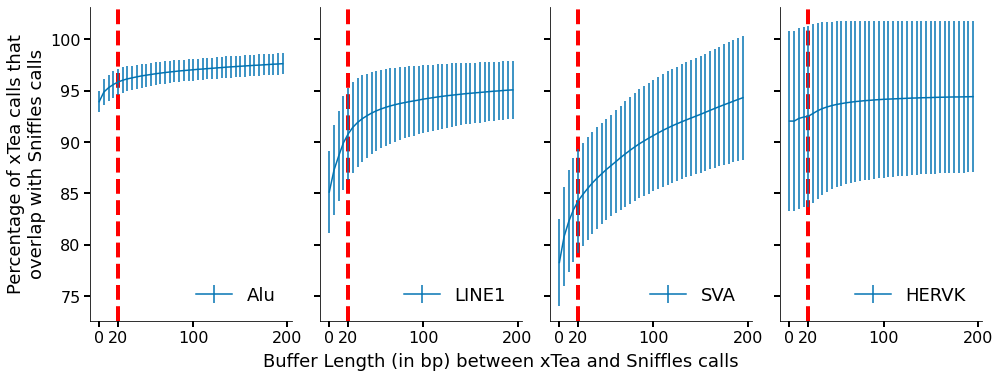

In [14]:
# Plot buffer length for truth set (i.e. between xtea and sniffles)

colors = sns.color_palette("colorblind", 4)

fig, axes = plt.subplots(1, 4, figsize=(14, 5), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten the 2x2 array for easy iteration

# Data and labels for plotting
data_labels = [
    ('Alu', 'ALU', colors[0]),
    ('LINE1', 'LINE1', colors[0]),
    ('SVA', 'SVA', colors[0]),
    ('HERVK', 'HERVK', colors[0])
]

for ax, (label, TE, color)  in zip(axes, data_labels):
    ax.axvline(20, color='r', linestyle='--', linewidth = 4)
    ax.errorbar(
        df_TEs[TE]['Buffer_len'],  # x-values
        df_TEs[TE]['xtea_and_sniffles_percentcaptured_mean'],  # y-values
        yerr=df_TEs[TE]['xtea_and_sniffles_percentcaptured_std'],  # error bars (standard deviation)
        label=label,  # label for the legend
        color=color
    )

    # Add labels for axes
    #ax.xlim(-1,100)
    #ax.ylim(75,102)
    tick_positions = [0, 20, 100, 200]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(['0', '20', '100', '200'], fontsize=16)
    ax.tick_params(axis='both', which='major', labelsize=16, width=2, length=6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if TE == 'ALU':
        ax.set_ylabel('Percentage of xTea calls that\noverlap with Sniffles calls', fontsize=18)
    
    # Add a legend
    ax.legend(fontsize=18, frameon=False, loc=4)
    
fig.text(0.5, -0.03, 'Buffer Length (in bp) between xTea and Sniffles calls', ha='center', fontsize=18)

plt.tight_layout()
#plt.savefig(f'Output_7478/Benchmark_xTeaSniffles.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
import os
import numpy as np
import pandas as pd

# output directory
output_dir = os.path.expanduser("~/TE_work/data/instruth")
os.makedirs(output_dir, exist_ok=True)

# defining a function that compares calls by xtea and sniffles
# to give out calls reported by both with genotype

def calls_by_both(sample, TE, buffer):

    out_dict = {
        'CHROM': [],
        'POS': [],
        'SVLEN': [],
        'GT': []
    }

    xtea_df = xtea_results[f'{sample}_{TE}']
    sniffles_df = sniffles_results[sample]

    # group sniffles by chromosome once
    sniffles_by_chr = {
        chrom: df.reset_index(drop=True)
        for chrom, df in sniffles_df.groupby('CHROM')
    }

    # process chromosome-wise
    for chrom, xtea_chr in xtea_df.groupby('CHROM'):

        if chrom not in sniffles_by_chr:
            continue

        sniff_chr = sniffles_by_chr[chrom]

        sniff_pos = sniff_chr['POS'].to_numpy()
        sniff_svlen = sniff_chr['SVLEN'].to_numpy()

        # iterate through xtea calls
        for _, xtea_row in xtea_chr.iterrows():

            xpos = xtea_row['POS']
            xsvlen = len(xtea_row['insertion sequence'])

            # vectorized filtering
            nearby_mask = (
                (np.abs(sniff_pos - xpos) <= buffer) &
                (np.abs(sniff_svlen - xsvlen) < 500)
            )

            if not nearby_mask.any():
                continue

            candidate_rows = sniff_chr.loc[nearby_mask]

            for _, sniffles_row in candidate_rows.iterrows():

                # skip homozygous reference
                if sniffles_row['SAMPLE.GT'] == f"{sniffles_row['REF']}/{sniffles_row['REF']}":
                    continue

                out_dict['CHROM'].append(chrom)
                out_dict['POS'].append(xpos)
                out_dict['SVLEN'].append(xsvlen)

                if sniffles_row['SAMPLE.GT'] == f"{sniffles_row['REF']}/{sniffles_row['ALT']}":
                    GT = '0/1'

                elif sniffles_row['SAMPLE.GT'] == f"{sniffles_row['ALT']}/{sniffles_row['ALT']}":
                    GT = '1/1'

                else:
                    GT = './.'

                out_dict['GT'].append(GT)

                # keep first valid match only
                break

    return pd.DataFrame(out_dict)


# saving the truth set for each sample
truth_set = {}

# combined dataframe across all samples
combined_truth_sets = []

buffer_len_xTeaSniffles = [20]

for buffer in buffer_len_xTeaSniffles:

    for sample in samples:

        for TE in ['ALU', 'LINE1']:

            key = f'{sample}_{TE}_{buffer}'

            df = calls_by_both(sample, TE, buffer)

            truth_set[key] = df

            # save per-sample output
            out_file = f"{output_dir}/{key}.csv"
            df.to_csv(out_file, index=False)

            # create combined dataframe version
            combined_df = df.copy()

            combined_df['sample'] = sample
            combined_df['TE'] = TE
            combined_df['buffer'] = buffer

            combined_truth_sets.append(combined_df)

            print(f"Saved {key} -> {out_file}")


# concatenate all truth sets together
combined_truth_set_df = pd.concat(
    combined_truth_sets,
    ignore_index=True
)

# reorder columns
combined_truth_set_df = combined_truth_set_df[
    ['sample', 'TE', 'buffer', 'CHROM', 'POS', 'SVLEN', 'GT']
]

# save combined dataframe
combined_outfile = f"{output_dir}/combined_truth_set.csv"

combined_truth_set_df.to_csv(
    combined_outfile,
    index=False
)

print()
print(f"Combined truth set saved -> {combined_outfile}")
print(f"Total rows: {len(combined_truth_set_df)}")

Saved AP97317807JI_ALU_20 -> /gpfs/data/user/shreyags/TE_work/data/instruth/AP97317807JI_ALU_20.csv
Saved AP97317807JI_LINE1_20 -> /gpfs/data/user/shreyags/TE_work/data/instruth/AP97317807JI_LINE1_20.csv
Saved AR21470926BU_ALU_20 -> /gpfs/data/user/shreyags/TE_work/data/instruth/AR21470926BU_ALU_20.csv
Saved AR21470926BU_LINE1_20 -> /gpfs/data/user/shreyags/TE_work/data/instruth/AR21470926BU_LINE1_20.csv
Saved BV84758993ZD_ALU_20 -> /gpfs/data/user/shreyags/TE_work/data/instruth/BV84758993ZD_ALU_20.csv
Saved BV84758993ZD_LINE1_20 -> /gpfs/data/user/shreyags/TE_work/data/instruth/BV84758993ZD_LINE1_20.csv
Saved CS37349708SW_ALU_20 -> /gpfs/data/user/shreyags/TE_work/data/instruth/CS37349708SW_ALU_20.csv
Saved CS37349708SW_LINE1_20 -> /gpfs/data/user/shreyags/TE_work/data/instruth/CS37349708SW_LINE1_20.csv
Saved EE01709405UW_ALU_20 -> /gpfs/data/user/shreyags/TE_work/data/instruth/EE01709405UW_ALU_20.csv
Saved EE01709405UW_LINE1_20 -> /gpfs/data/user/shreyags/TE_work/data/instruth/EE0170

In [14]:
combined_truth_set_df.head(2)

,sample,TE,buffer,CHROM,POS,SVLEN,GT
0,AP97317807JI,ALU,20,chr1,247405670,57,0/1
1,AP97317807JI,ALU,20,chr1,1993705,100,1/1


In [16]:
# Compare MELT results with the truth set for different filters and outputs precision, recall and F1 scores

## filter = none, filter1, filter2, filter3, filter4, transduction
# filter1 = FILTER == PASS & ASSESS == 3 or 4 or 5
# filter2 = FILTER == PASS & ASSESS == 5
# filter3 = FILTER == PASS or lc & ASSESS == 3 or 4 or 5
#filter4 = FILTER == PASS or lc & ASSESS == 5
#transduction = filter4 + calls with transduction evidence
def get_precision_recall_F1_melt(sample, TE, filter, bufferMELT, bufferxTeaSniffles):
    truth_df = truth_set[f'{sample}_{TE}_{bufferxTeaSniffles}']
    MELT_df = MELT_results[f'{sample}_{TE}']

    #print(MELT_df)
    
    #if TE == 'LINE1':
        #MELT_df = MELT_transduction_results[sample].fillna('none')
    
    if filter == 'filter1':
        MELT_df = MELT_df[(MELT_df['FILTER'] == 'PASS') & (MELT_df['ASSESS'].isin([3, 4, 5]))]
    elif filter == 'filter2':
        MELT_df = MELT_df[(MELT_df['FILTER'] == 'PASS') & (MELT_df['ASSESS'] == 5)]
    elif filter == 'filter3':
        MELT_df = MELT_df[((MELT_df['FILTER'] == 'PASS') | (MELT_df['FILTER'] == 'lc')) & (MELT_df['ASSESS'].isin([3, 4, 5]))]
    elif filter == 'filter4':
        MELT_df = MELT_df[((MELT_df['FILTER'] == 'PASS') | (MELT_df['FILTER'] == 'lc')) & (MELT_df['ASSESS'] == 5)]
    #elif filter == 'transduction':
        #if TE == 'LINE1':
            #MELT_df = MELT_df[(MELT_df['METRANS'] != 'none') | (((MELT_df['FILTER'] == 'PASS') | (MELT_df['FILTER'] == 'lc')) & (MELT_df['ASSESS'] == 5))]
        #else:
            #MELT_df = MELT_df[((MELT_df['FILTER'] == 'PASS') | (MELT_df['FILTER'] == 'lc')) & (MELT_df['ASSESS'] == 5)]
            
    MELT_df = MELT_df.reset_index(drop=True)

    # Filter rows based on chromosome match
    merged_df = pd.merge(
        MELT_df[['CHROM', 'POS']],
        truth_df[['CHROM', 'POS', 'SVLEN', 'GT']],
        on='CHROM',
        how='inner'
    )

    # Convert 'POS_x' and 'POS_y' columns to float if they aren't already
    merged_df['POS_x'] = merged_df['POS_x'].astype(float)
    merged_df['POS_y'] = merged_df['POS_y'].astype(float)

    # Calculate the position difference
    #merged_df['POS_DIFF'] = -(merged_df['POS_x'] - merged_df['POS_y'])
    merged_df['POS_DIFF'] = abs(merged_df['POS_x'] - merged_df['POS_y'])

    # Filter by buffer
    #valid_rows = merged_df[(merged_df['POS_DIFF'] >= 0) & (merged_df['POS_DIFF'] <= bufferMELT)]
    valid_rows = merged_df[(merged_df['POS_DIFF'] <= bufferMELT)]


    # Counts
    TP = len(valid_rows)
    FP = len(MELT_df) - TP
    FN = len(truth_df) - TP
    precision = round(TP/len(MELT_df), 3)
    recall = round(TP/len(truth_df), 3)
    F1 = round((2*TP)/(2*TP+FP+FN), 3)

    return precision, recall, F1, TP, FP, FN


bufferMELT_list = [0, 5, 10, 15, 20, 25, 50]
bufferxTeaSniffles_list = [0, 20]
filters_list = ['none', 'filter1', 'filter2', 'filter3', 'filter4']
TEs_list = ['ALU','LINE1', 'SVA', 'HERVK']
results = []
df_TEs_melttruth = {}

for TE in TEs_list:
    results = [
        {
            'TE': TE,
            'bufferxTeaSniffles': bufferxTeaSniffles,
            'bufferMELT': bufferMELT,
            'filter': filter,
            'precision_mean': round(np.mean(precision := [get_precision_recall_F1_melt(sample, TE, filter, bufferMELT, bufferxTeaSniffles)[0] for sample in samples]), 2),
            'precision_sd': round(np.std(precision), 2),
            'recall_mean': round(np.mean(recall := [get_precision_recall_F1_melt(sample, TE, filter, bufferMELT, bufferxTeaSniffles)[1] for sample in samples]), 2),
            'recall_sd': round(np.std(recall), 2),
            'F1_mean': round(np.mean(F1 := [get_precision_recall_F1_melt(sample, TE, filter, bufferMELT, bufferxTeaSniffles)[2] for sample in samples]), 2),
            'F1_sd': round(np.std(F1), 2)
        }
        for bufferxTeaSniffles in bufferxTeaSniffles_list
        for bufferMELT in bufferMELT_list
        for filter in filters_list
    ]

    # Store results for each TE in a DataFrame
    df_TEs_melttruth[TE] = pd.DataFrame(results)

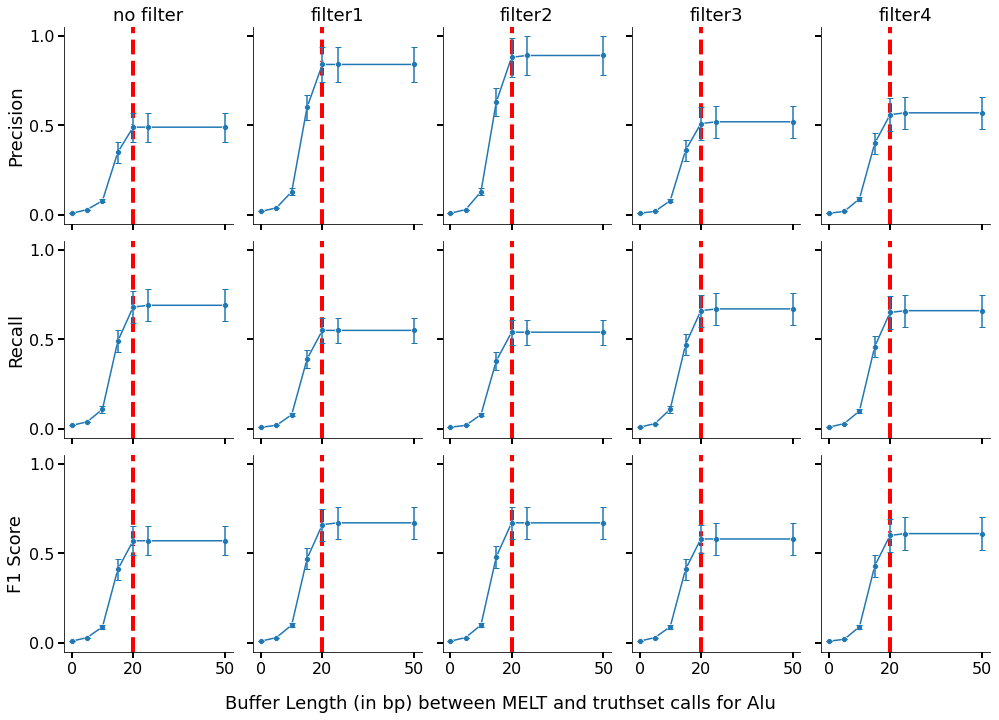

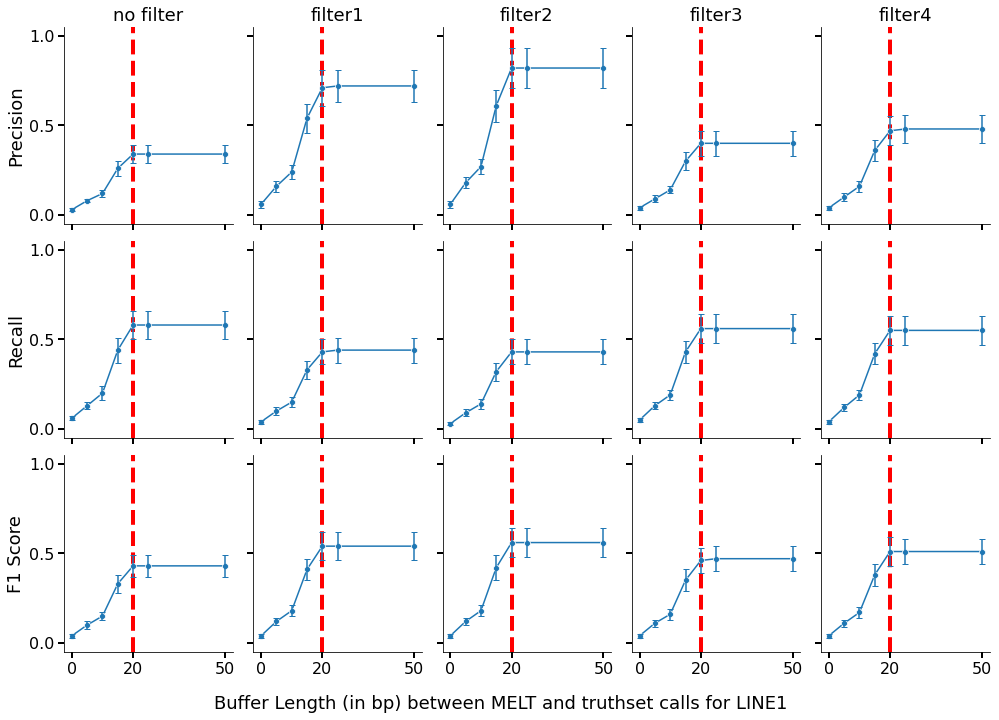

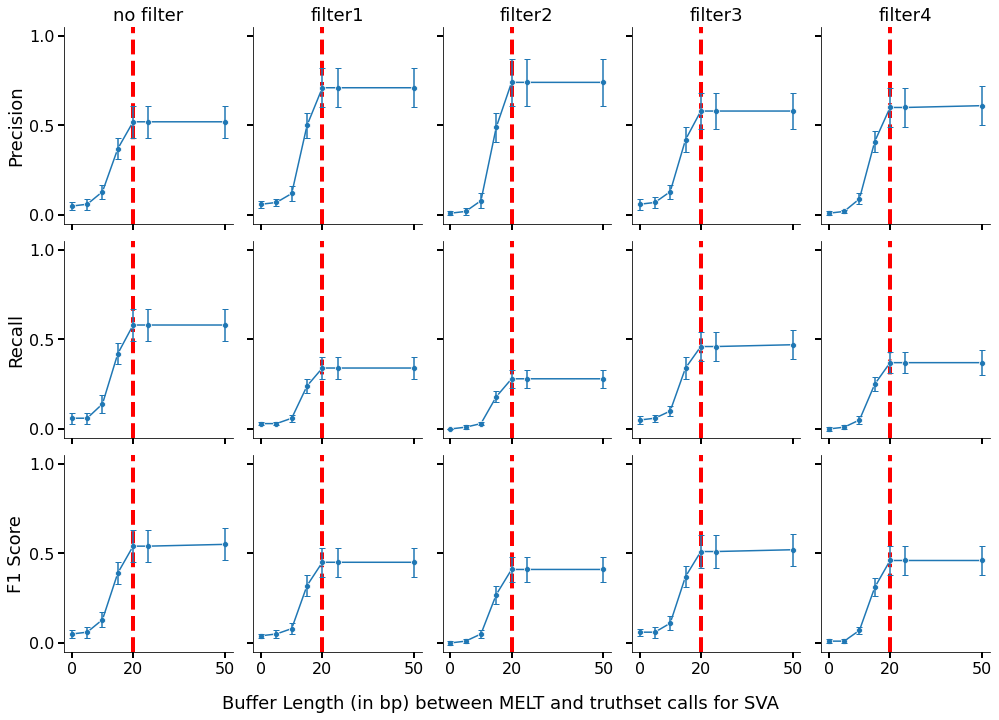

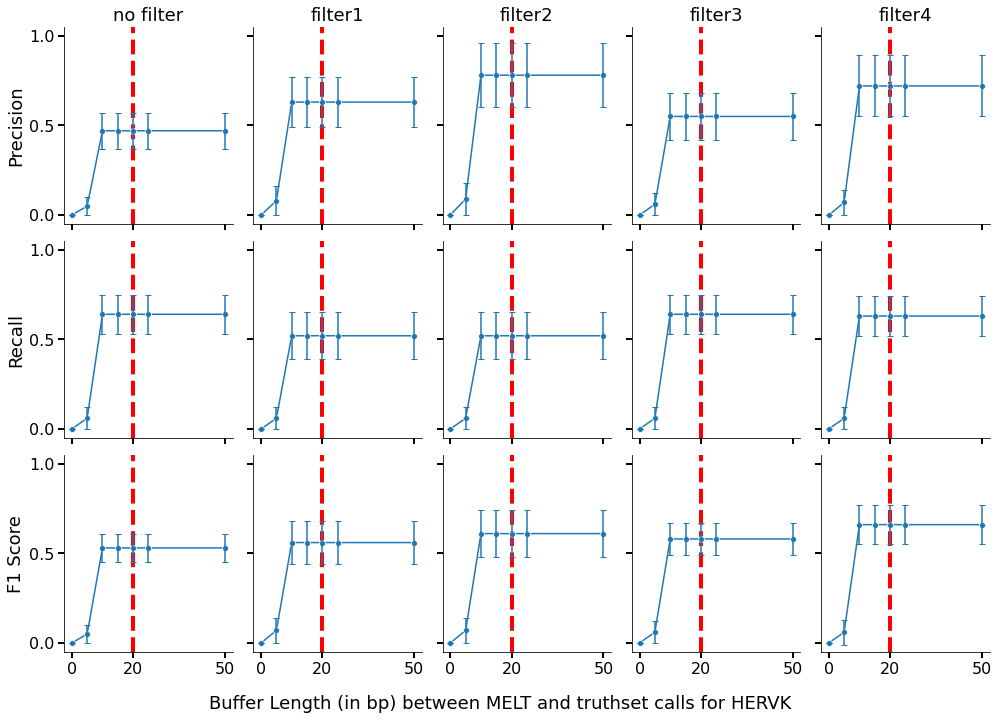

In [18]:
# updated filters list to leave out transductions
filters_list = ['none', 'filter1', 'filter2', 'filter3', 'filter4']
xtick_positions = [0, 20, 50]
ytick_positions = [0, 0.5, 1]

# df_TEs is a dictionary of DataFrames where each TE has its respective DataFrame
for TE in TEs_list:
    # Get the DataFrame for the current TE
    df = df_TEs_melttruth[TE]
    
    # Create a figure with 5 columns (for each filter) and 3 rows (for precision, recall, F1)
    fig, axes = plt.subplots(3, 5, figsize=(14, 10), sharex=True, sharey=True)
    #fig.suptitle(f'Precision, Recall, and F1 for {TE}', fontsize=16)

    # Loop over each filter
    for i, filter in enumerate(filters_list):
        # Filter data for the current filter
        #df_filter = df[df['filter'] == filter]
        df_filter = df[(df['filter'] == filter) & (df['bufferxTeaSniffles'] == 20)]

        # Precision Plot (1st row) with error bars
        ax_precision = axes[0, i]
        ax_precision.axvline(20, color='r', linestyle='--', linewidth = 4)
        sns.lineplot(
            data=df_filter,
            x='bufferMELT',
            y='precision_mean',
            ax=ax_precision,
            marker='o',
            errorbar=None,
            #palette='bright'
        )
        
        # Add error bars manually
        #for bufferx in bufferxTeaSniffles_list:
        for bufferx in [20]:
            buffer_data = df_filter[df_filter['bufferxTeaSniffles'] == bufferx]
            ax_precision.errorbar(buffer_data['bufferMELT'], buffer_data['precision_mean'], yerr=buffer_data['precision_sd'], fmt='none', capsize=3)

        ax_precision.set_ylim(-0.05, 1.05)
        ax_precision.set_xticks(xtick_positions)
        ax_precision.set_yticks(ytick_positions)
        ax_precision.set_yticklabels(['0.0', '0.5', '1.0'], fontsize=16)
        
        if filter=="none":
            ax_precision.set_title("no filter", fontsize=18)
        else:
            ax_precision.set_title(f'{filter}', fontsize=18)
        ax_precision.set_ylabel('Precision', fontsize=18)
        #if filter=="filter4":
        #    ax_precision.legend(title='bufferxTeaSniffles', fontsize=18, title_fontsize=18)
        #else:
        #    ax_precision.legend().remove()
        ax_precision.tick_params(axis='both', which='major', labelsize=16, width=2, length=6)
        ax_precision.spines['top'].set_visible(False)
        ax_precision.spines['right'].set_visible(False)

        # Recall Plot (2nd row) with error bars
        ax_recall = axes[1, i]
        ax_recall.axvline(20, color='r', linestyle='--', linewidth = 4)
        
        sns.lineplot(
            data=df_filter,
            x='bufferMELT',
            y='recall_mean',
            #hue='bufferxTeaSniffles',
            ax=ax_recall,
            marker='o',
            errorbar=None,
            #palette='bright'
        )
        
        # Add error bars manually
        #for bufferx in bufferxTeaSniffles_list:
        for bufferx in [20]:
            buffer_data = df_filter[df_filter['bufferxTeaSniffles'] == bufferx]
            ax_recall.errorbar(buffer_data['bufferMELT'], buffer_data['recall_mean'], yerr=buffer_data['recall_sd'], fmt='none', capsize=3)

        ax_recall.set_ylim(-0.05, 1.05)
        #ax_recall.set_title(f'Recall ({filter})')
        ax_recall.set_xticks(xtick_positions)
        ax_recall.set_ylabel('Recall', fontsize=18)
        #ax_recall.legend().remove()  # Remove the legend to avoid clutter
        ax_recall.tick_params(axis='both', which='major', labelsize=16, width=2, length=6)
        ax_recall.spines['top'].set_visible(False)
        ax_recall.spines['right'].set_visible(False)

        # F1 Score Plot (3rd row) with error bars
        ax_f1 = axes[2, i]
        ax_f1.axvline(20, color='r', linestyle='--', linewidth = 4)
        sns.lineplot(
            data=df_filter,
            x='bufferMELT',
            y='F1_mean',
            #hue='bufferxTeaSniffles',
            ax=ax_f1,
            marker='o',
            errorbar=None,
            #palette='bright'
        )
        # Add error bars manually
        #for bufferx in bufferxTeaSniffles_list:
        for bufferx in [20]:
            buffer_data = df_filter[df_filter['bufferxTeaSniffles'] == bufferx]
            ax_f1.errorbar(buffer_data['bufferMELT'], buffer_data['F1_mean'], yerr=buffer_data['F1_sd'], fmt='none', capsize=3)

        ax_f1.set_ylim(-0.05, 1.05)
        #ax_f1.set_title(f'F1 Score ({filter})')
        ax_f1.set_xticks(xtick_positions)
        ax_f1.set_xticklabels(['0', '20', '50'], fontsize=16)
        ax_f1.set_xlabel('', fontsize=18)
        ax_f1.set_ylabel('F1 Score', fontsize=18)
        #ax_f1.legend().remove()  # Remove the legend to avoid clutter
        ax_f1.tick_params(axis='both', which='major', labelsize=16, width=2, length=6)
        ax_f1.spines['top'].set_visible(False)
        ax_f1.spines['right'].set_visible(False)

    if TE=="ALU":
        TE="Alu"
    fig.text(0.5, -0.03, f'Buffer Length (in bp) between MELT and truthset calls for {TE}', ha='center', fontsize=18)

    # Adjust layout and save
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for the main title
    #plt.savefig(f'Output_7478/precision_recall_f1_{TE}_7478.png', dpi=300, bbox_inches='tight')
    plt.show()

In [19]:
for TE in TEs_list:
    results = []
    #for bufferxTeaSniffles in bufferxTeaSniffles_list:
    for bufferxTeaSniffles in [20]:
        #for bufferMELT in bufferMELT_list:
        for bufferMELT in [20]:
            for filter in filters_list:
            #for filter in ['filter2']:
                precision = []
                recall = []
                F1 = []
                TP = []
                FP = []
                FN = []
                for sample in samples:
                    p, r, f, tp, fp, fn = get_precision_recall_F1_melt(sample, TE, filter, bufferMELT, bufferxTeaSniffles)
                    precision.append(p)
                    recall.append(r)
                    F1.append(f)
                    TP.append(tp)
                    FP.append(fp)
                    FN.append(fn)

                # Calculate mean and standard deviation
                precision_mean = round(np.mean(precision), 2)
                precision_sd = round(np.std(precision), 2)
                recall_mean = round(np.mean(recall), 2)
                recall_sd = round(np.std(recall), 2)
                F1_mean = round(np.mean(F1), 2)
                F1_sd = round(np.std(F1), 2)
                TP_mean = round(np.mean(TP), 2)
                TP_sd = round(np.std(TP), 2)
                FP_mean = round(np.mean(FP), 2)
                FP_sd = round(np.std(FP), 2)
                FN_mean = round(np.mean(FN), 2)
                FN_sd = round(np.std(FN), 2)
                

                results.append({'TE': TE, 'bufferxTeaSniffles': bufferxTeaSniffles, 'bufferMELT': bufferMELT, 'filter': filter, 'precision': f'{precision_mean}±{precision_sd}', 'recall': f'{recall_mean}±{recall_sd}', 'F1': f'{F1_mean}±{F1_sd}', 'TP': f'{TP_mean}±{TP_sd}', 'FP': f'{FP_mean}±{FP_sd}', 'FN': f'{FN_mean}±{FN_sd}'})
                #results.append({'TE': TE, 'bufferxTeaSniffles': bufferxTeaSniffles, 'bufferMELT': bufferMELT, 'filter': filter, 'precision_mean': precision_mean, 'precision_sd': precision_sd, 'recall_mean': recall_mean, 'recall_sd': recall_sd, 'F1_mean': F1_mean, 'F1_sd': F1_sd})
    df_TEs[TE] = pd.DataFrame(results)
    results = []

from tabulate import tabulate

# Print DataFrame in a neat table format
print(tabulate(df_TEs['ALU'], headers='keys', tablefmt='fancy_grid', showindex=False))
print(tabulate(df_TEs['LINE1'], headers='keys', tablefmt='fancy_grid', showindex=False))
print(tabulate(df_TEs['SVA'], headers='keys', tablefmt='fancy_grid', showindex=False))
print(tabulate(df_TEs['HERVK'], headers='keys', tablefmt='fancy_grid', showindex=False))

╒══════╤══════════════════════╤══════════════╤══════════╤═════════════╤═══════════╤═══════════╤════════════════╤════════════════╤═══════════════╕
│ TE   │   bufferxTeaSniffles │   bufferMELT │ filter   │ precision   │ recall    │ F1        │ TP             │ FP             │ FN            │
╞══════╪══════════════════════╪══════════════╪══════════╪═════════════╪═══════════╪═══════════╪════════════════╪════════════════╪═══════════════╡
│ ALU  │                   20 │           20 │ none     │ 0.49±0.08   │ 0.68±0.09 │ 0.57±0.08 │ 1060.44±132.67 │ 1126.69±284.74 │ 498.0±155.55  │
├──────┼──────────────────────┼──────────────┼──────────┼─────────────┼───────────┼───────────┼────────────────┼────────────────┼───────────────┤
│ ALU  │                   20 │           20 │ filter1  │ 0.84±0.1    │ 0.55±0.07 │ 0.66±0.09 │ 848.31±106.04  │ 162.62±105.82  │ 710.12±129.32 │
├──────┼──────────────────────┼──────────────┼──────────┼─────────────┼───────────┼───────────┼────────────────┼────────────